In [1]:
# ==========================================
# HealthAI Pro - Disease Prediction ML Model
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import joblib
import warnings
warnings.filterwarnings("ignore")

In [2]:
training_df = pd.read_csv("training.csv")
severity_df = pd.read_csv("Symptom-severity.csv")
description_df = pd.read_csv("symptom_Description.csv")
precaution_df = pd.read_csv("symptom_precaution.csv")

print("Training Dataset Shape:", training_df.shape)
print("Severity Dataset Shape:", severity_df.shape)
print("Description Dataset Shape:", description_df.shape)
print("Precaution Dataset Shape:", precaution_df.shape)

training_df.head()

Training Dataset Shape: (4924, 136)
Severity Dataset Shape: (133, 2)
Description Dataset Shape: (41, 2)
Precaution Dataset Shape: (41, 5)


,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,Urinating_a_lot,Heartburn,prognosis,medicine
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,"Topical antifungals, oral antifungals"
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,"Topical antifungals, oral antifungals"
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,"Topical antifungals, oral antifungals"
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,"Topical antifungals, oral antifungals"
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,"Topical antifungals, oral antifungals"


In [3]:
# ==========================================
# DATA CLEANING
# ==========================================

# Remove unwanted columns if they exist
training_df = training_df.drop(
    columns=[
        "Unnamed: 133",
        "medicine"
    ],
    errors="ignore"
)

# Remove duplicate rows
training_df = training_df.drop_duplicates()

# Clean column names
training_df.columns = training_df.columns.str.strip()

print("Cleaned Dataset Shape:", training_df.shape)

training_df.head()

Cleaned Dataset Shape: (308, 135)


,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,Urinating_a_lot,Heartburn,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection


In [4]:
# ==========================================
# FEATURE / TARGET SPLIT
# ==========================================

X = training_df.drop(
    columns=["prognosis"]
)

y = training_df["prognosis"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (308, 134)
Target Shape: (308,)


In [5]:
# ==========================================
# LABEL ENCODING
# ==========================================

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

# Disease Mapping
disease_mapping = dict(
    zip(
        encoder.classes_,
        range(len(encoder.classes_))
    )
)

print("Total Diseases:", len(disease_mapping))

list(disease_mapping.items())[:10]

Total Diseases: 43


[('(vertigo) Paroymsal  Positional Vertigo', 0),
 ('AIDS', 1),
 ('Acne', 2),
 ('Alcoholic hepatitis', 3),
 ('Allergy', 4),
 ('Arthritis', 5),
 ('Bronchial Asthma', 6),
 ('Cervical spondylosis', 7),
 ('Chicken pox', 8),
 ('Chikungunya', 9)]

In [7]:
# ==========================================
# TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42
)

print("X Train Shape:", X_train.shape)
print("X Test Shape:", X_test.shape)

X Train Shape: (246, 134)
X Test Shape: (62, 134)


In [8]:
# ==========================================
# MODEL COMPARISON
# ==========================================

models = {

    "Logistic Regression":
    LogisticRegression(max_iter=1000),

    "Decision Tree":
    DecisionTreeClassifier(random_state=42),

    "Random Forest":
    RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "Support Vector Machine":
    SVC()
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    acc = accuracy_score(
        y_test,
        preds
    )

    results.append([
        name,
        round(acc * 100, 2)
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy (%)"
    ]
)

results_df

,Model,Accuracy (%)
0,Logistic Regression,98.39
1,Decision Tree,70.97
2,Random Forest,98.39
3,Support Vector Machine,98.39


In [9]:

# ==========================================
# FINAL MODEL SELECTION
# ==========================================

final_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

final_model.fit(
    X_train,
    y_train
)

final_preds = final_model.predict(
    X_test
)

final_accuracy = accuracy_score(
    y_test,
    final_preds
)

print(
    f"Final Random Forest Accuracy: {final_accuracy * 100:.2f}%"
)

Final Random Forest Accuracy: 98.39%


In [12]:
print(classification_report(y_test, final_preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         2
           4       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3
           7       1.00      1.00      1.00         2
           8       1.00      1.00      1.00         3
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         2
          12       1.00      0.50      0.67         2
          14       1.00      1.00      1.00         2
          16       1.00      1.00      1.00         1
          17       1.00      1.00      1.00         1
          20       1.00      1.00      1.00         2
          22       1.00      1.00      1.00         2
          23       1.00      1.00      1.00         3
          24       1.00    

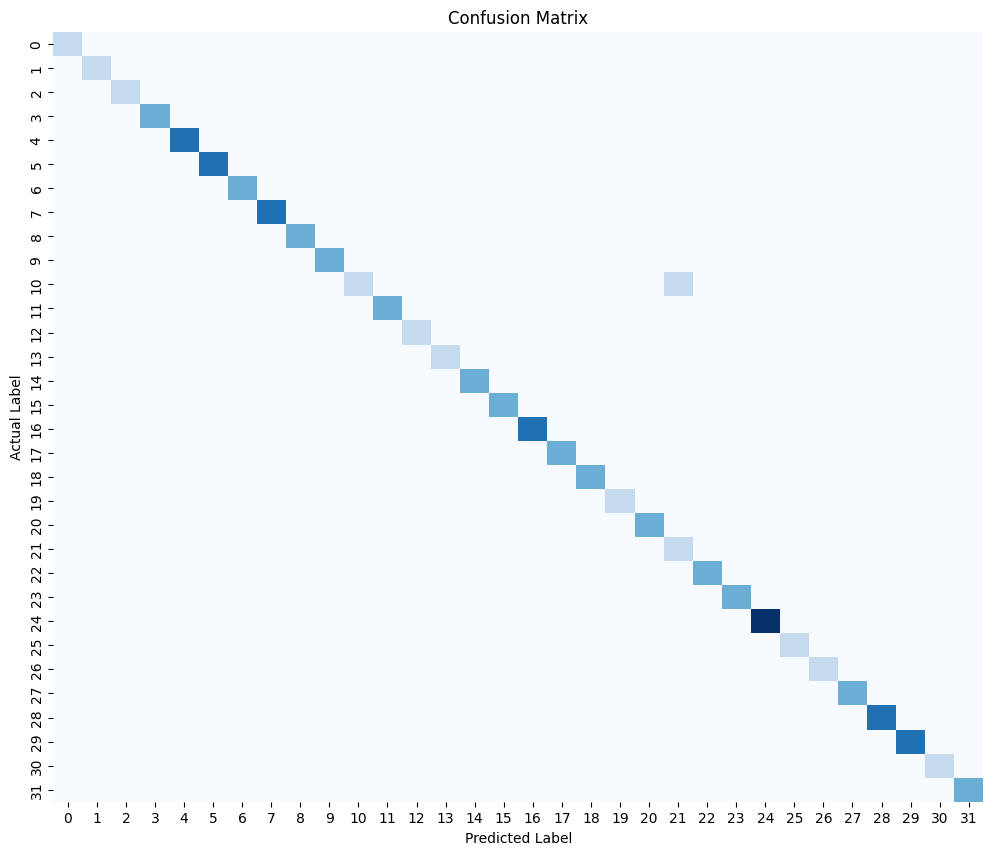

In [13]:
# ==========================================
# CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(
    y_test,
    final_preds
)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    cmap="Blues",
    cbar=False
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

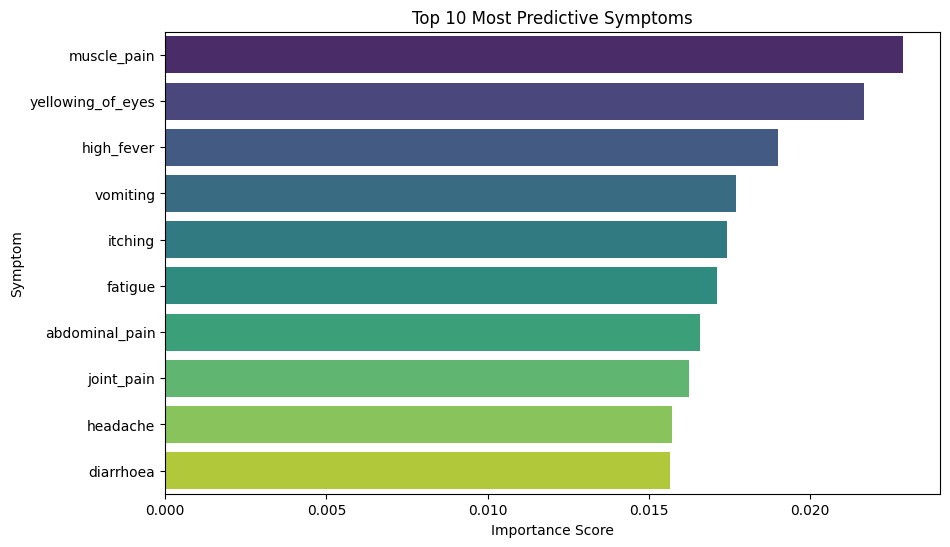

In [14]:
# ==========================================
# TOP SYMPTOM IMPORTANCE
# ==========================================

feature_importance = pd.Series(
    final_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=feature_importance[:10],
    y=feature_importance.index[:10],
    palette="viridis"
)

plt.title("Top 10 Most Predictive Symptoms")

plt.xlabel("Importance Score")
plt.ylabel("Symptom")

plt.show()

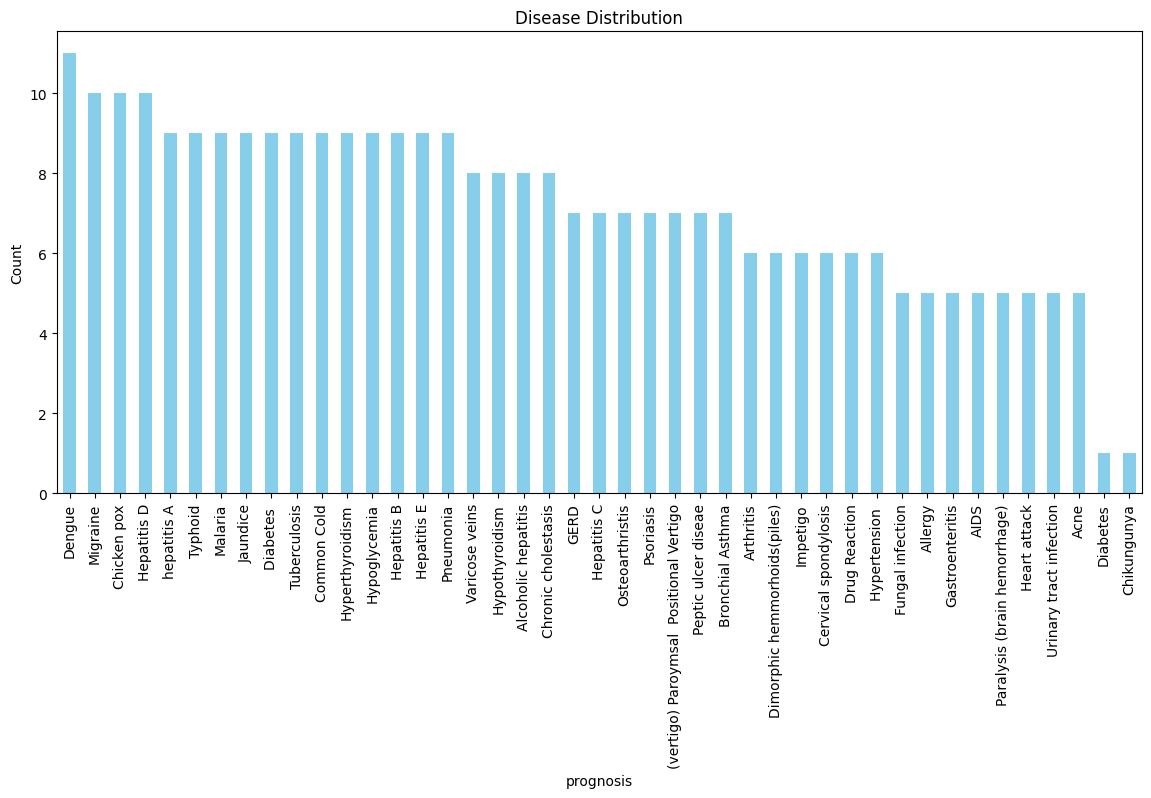

In [15]:
# ==========================================
# DISEASE DISTRIBUTION
# ==========================================

plt.figure(figsize=(14, 6))

training_df["prognosis"].value_counts().plot(
    kind="bar",
    color="skyblue"
)

plt.title("Disease Distribution")

plt.ylabel("Count")

plt.xticks(rotation=90)

plt.show()

In [16]:
# ==========================================
# PREDICTION FUNCTION
# ==========================================

all_symptoms = X.columns.tolist()

def predict_disease(symptoms_list):

    input_vector = np.zeros(
        len(all_symptoms)
    )

    for symptom in symptoms_list:

        if symptom in all_symptoms:

            idx = all_symptoms.index(symptom)

            input_vector[idx] = 1

    prediction = final_model.predict(
        [input_vector]
    )[0]

    disease = encoder.inverse_transform(
        [prediction]
    )[0]

    confidence = np.max(
        final_model.predict_proba(
            [input_vector]
        )
    )

    return disease, confidence

In [17]:
# ==========================================
# TEST PREDICTION
# ==========================================

sample_symptoms = [
    "itching",
    "skin_rash",
    "nodal_skin_eruptions"
]

disease, confidence = predict_disease(
    sample_symptoms
)

print("Predicted Disease:", disease)

print(
    f"Confidence Score: {confidence * 100:.2f}%"
)

Predicted Disease: Fungal infection
Confidence Score: 80.00%


In [18]:
# ==========================================
# RECOMMENDATION DATASET CREATION
# ==========================================

description_df.columns = description_df.columns.str.strip()
precaution_df.columns = precaution_df.columns.str.strip()

master_recommendations = pd.merge(
    description_df,
    precaution_df,
    on="Disease",
    how="left"
)

master_recommendations.to_csv(
    "master_recommendations.csv",
    index=False
)

print("Master recommendation file created successfully.")
master_recommendations.head()

Master recommendation file created successfully.


,Disease,Description,Precaution_1,Precaution_2,Precaution_3,Precaution_4
0,Drug Reaction,An adverse drug reaction (ADR) is an injury ca...,stop irritation,consult nearest hospital,stop taking drug,follow up
1,Malaria,An infectious disease caused by protozoan para...,Consult nearest hospital,avoid oily food,avoid non veg food,keep mosquitos out
2,Allergy,An allergy is an immune system response to a f...,apply calamine,cover area with bandage,NaN,use ice to compress itching
3,Hypothyroidism,"Hypothyroidism, also called underactive thyroi...",reduce stress,exercise,eat healthy,get proper sleep
4,Psoriasis,Psoriasis is a common skin disorder that forms...,wash hands with warm soapy water,stop bleeding using pressure,consult doctor,salt baths


In [19]:
# ==========================================
# SEVERITY SCORE SYSTEM
# ==========================================

severity_df.columns = severity_df.columns.str.strip()

severity_df["Symptom"] = (
    severity_df["Symptom"]
    .astype(str)
    .str.replace("_", " ")
    .str.lower()
    .str.strip()
)

severity_dict = dict(
    zip(
        severity_df["Symptom"],
        severity_df["weight"]
    )
)

def calculate_severity(symptoms_list):

    score = 0

    for symptom in symptoms_list:

        clean_symptom = (
            symptom
            .replace("_", " ")
            .lower()
            .strip()
        )

        score += severity_dict.get(
            clean_symptom,
            0
        )

    if score >= 15:
        risk_level = "High"
    elif score >= 8:
        risk_level = "Moderate"
    else:
        risk_level = "Low"

    return score, risk_level

In [20]:
# ==========================================
# FULL HEALTH REPORT FUNCTION
# ==========================================

def generate_health_report(symptoms_list):

    disease, confidence = predict_disease(
        symptoms_list
    )

    score, risk_level = calculate_severity(
        symptoms_list
    )

    disease_info = master_recommendations[
        master_recommendations["Disease"].astype(str).str.lower()
        ==
        disease.lower()
    ]

    if not disease_info.empty:

        row = disease_info.iloc[0]

        description = row["Description"]

        precautions = [
            row.get("Precaution_1", ""),
            row.get("Precaution_2", ""),
            row.get("Precaution_3", ""),
            row.get("Precaution_4", "")
        ]

    else:

        description = "No description available."

        precautions = [
            "Consult a healthcare professional."
        ]

    return {
        "Disease": disease,
        "Confidence": round(confidence * 100, 2),
        "Severity Score": score,
        "Risk Level": risk_level,
        "Description": description,
        "Precautions": precautions
    }

In [21]:
# ==========================================
# TEST FULL HEALTH REPORT
# ==========================================

report = generate_health_report([
    "itching",
    "skin_rash",
    "nodal_skin_eruptions"
])

report

{'Disease': 'Fungal infection',
 'Confidence': np.float64(80.0),
 'Severity Score': 8,
 'Risk Level': 'Moderate',
 'Description': 'In humans, fungal infections occur when an invading fungus takes over an area of the body and is too much for the immune system to handle. Fungi can live in the air, soil, water, and plants. There are also some fungi that live naturally in the human body. Like many microbes, there are helpful fungi and harmful fungi.',
 'Precautions': ['bath twice',
  'use detol or neem in bathing water',
  'keep infected area dry',
  'use clean cloths']}

In [22]:
# ==========================================
# SAVE FINAL MODEL FILES
# ==========================================

joblib.dump(
    final_model,
    "symptom_model.pkl"
)

joblib.dump(
    encoder,
    "label_encoder.pkl"
)

joblib.dump(
    all_symptoms,
    "symptom_columns.pkl"
)

print("Model files saved successfully:")
print("- symptom_model.pkl")
print("- label_encoder.pkl")
print("- symptom_columns.pkl")

Model files saved successfully:
- symptom_model.pkl
- label_encoder.pkl
- symptom_columns.pkl
